# Intro to TF 101

## What is Tensorflow?


 > TensorFlow is an open-source machine learning framework used in data science and artificial intelligence. It represents data as tensors and operates on them through a computational graph. It's popular for deep learning, offering high-level APIs for neural networks. TensorFlow is flexible, scalable, and has a supportive community, making it a vital tool for master's students in machine learning and data science.

 _Cit: ChatGPT_

## What actually is Tensorflow?

It can be your best friend or your worst nightmare, depending on which background you have, and what platform you're using (but we luckly have Colab <3)

Tensorflow (from now on TF) is "mainly" a Numpy+"differentiation library" (it actually can do [muuuuch more than that](https://www.tensorflow.org/resources/libraries-extensions) but we don't care about it for the moment)... it has a little sister called Keras, which is nothing more that a set of tools that (hopefully) work out-of-the-box for DeepLearning

However, don't think that TF/Keras are just for DeepLearning... TF is used for any kind of (gradient) optimization, as we will see

## How to use it

Well, the first thing to do, it's definitely to check if Colab set this notebook to run on GPU, or tomorrow we might still be here waiting...

### Intro

Well importing it might be a nice starting step (and recall to rename it, a must, same for his little brother numpy)

In [6]:
import tensorflow as tf
import numpy as np

TF has many functionalities, that you can find in [the documentation](https://www.tensorflow.org/api_docs/python/tf), functionalities that encodes some sort of computations (data manipulation, activation functions, tensor manipulation and so on)

![](https://pbs.twimg.com/media/E10ffa9X0AA4H2_.png)

### Tensors


However, everything requires some sort of tensors (n-dimensional arrays), and there are a handful of versions that you might want to keep in mind.

In [7]:
# Constants, aka you can't change their value
# They can be scalars
your_constant = tf.constant(10)
# Or arrays
your_constant = tf.constant([10, 11])

In [8]:
# Tensors, which you can instead manipulate
your_tensor = tf.convert_to_tensor([10, 11])  #input is np.array

However, both of them have a very specific requirements, which is that whatever is inside, has to share the same type, and the whole framework is type-checked, so a int-tensor cannot be multiplied by a float tensor.

**PSA:** TF will try to deduce the type from whatever you are passing, so be very careful

In [9]:
# tf.constant(10) * tf.constant(11.)

In [10]:
tf.constant(10.) * tf.constant(11.)

<tf.Tensor: shape=(), dtype=float32, numpy=110.0>

You can enforce the type you want by using the `dtype` argument (present in almost all the functions of TF)

In [11]:
tf.constant(10, dtype=tf.float32) * tf.constant(11.)

<tf.Tensor: shape=(), dtype=float32, numpy=110.0>

or, you can cast it using `tf.cast`

In [12]:
tf.cast(tf.constant(10), dtype=tf.float32)

<tf.Tensor: shape=(), dtype=float32, numpy=10.0>

(everything is valid also for the tensors)

**PSA:** TF is very numpy friendly (they can go back and forth from np arrays to TF arrays), however, there is a very inconvenient scenario in both directions:  
 1. TF to np: you loose the gradient information (from the conversion on, tf will not register any operation and thus the gradient, we will see later what this means)
 2. np to TF: the casts tend to be using `float64`, where everything related to Deep Learning works in `float32` (yes, they are 2 different types)

In [13]:
tf.convert_to_tensor(np.array(10.))

<tf.Tensor: shape=(), dtype=float64, numpy=10.0>

Finally, if you add some computer science boilerplate wrapper around the `Tensor` class, you get the `Variable` class, which makes the TF life a bit easier in some cases (graph computation, will see it later)

![](https://i.redd.it/gpp8gmh0on861.jpg)

### Functions

TF provides a ton of functionalities, and it's useless list here all possible ones, however feel free to use ChatGPT if you need to find a function that does a certain computation, in my experience it knows TF pretty well when dealing with limited situations (don't ask to code everything in one go for you, it won't work most likely)

Heres the most useful ones:  
 1. `tf.nn` contains everything you can think that might be useful for neural networks
 2. `tf.keras` contains the Keras API
 3. `tf.optimizers` gradient optimizers
 4. `tf.random` everything dealing with randomness and sampling
 5. `tf.math` everything dealing with math functions

### Gradient

Gradients are a big part of Tensorflow, as it was born as an _automatic differentiation_ framework (God thanks for the chain-rule)

You can pretty much do anything gradient-related with `tf.GradientTape` (there are other ways, but personally I find this one the most elastic and clear one)

You can think `tf.GradientTape` as the BigBrother watching everything is happening under him (TF doesn't like privacy), and registering every step: if all such steps are performed with differentiable TF operations, he will apply the chain rule few millions times and hand you the gradient

In [14]:
# 1 - you create a variable:
v = tf.Variable(0.)

def f(x):
  return 2 * x
# 2 - you create the BigBrother
with tf.GradientTape() as tape:
  # 3 - you let the BigBrother spy on you
  y = f(v)

# 4 - you use the fruits of your privacy violation
tape.gradient(y, v) # dy / dv = df(x) / dx

<tf.Tensor: shape=(), dtype=float32, numpy=2.0>

However, TF always had the advantage over other frameworks to handle graph execution (they are catching up) over eager execution, heres a quick intro:
 1. eager execution: the one you always knew, it goes line by line and executes stuff on the fly
 2. graph execution: TF first checkes the operation graph of a function, sees if it can optimize it, and if so, simplifies/parallelize it (you have little power over what happens behind the scenes, but most of the times works just fine)  


 The whole point is that if in that function everything that happens is deterministing and never changes, it can create shorcuts (just like a compiler would do with your code), and make it faster for your GPU

In [15]:
# the @ notation is for _decorators_ in python (for the sake of the tutorial, you can consider it black magic)
@tf.function
def much_faster_function(v):
  return 2*v

v = tf.Variable(0.)
with tf.GradientTape() as tape:
  res = much_faster_function(v)

tape.gradient(res, v)

<tf.Tensor: shape=(), dtype=float32, numpy=2.0>

## Let's start doing interesting stuff

If you got everything to this point, you are pretty much able to code anything in the DeepLearning community, well done

![](https://media.tenor.com/JHZWHc6hZgoAAAAC/thumbs-up-kid.gif)

As for all respected optimization tutorials, why not starting from our favourite model implementing it together...

linear regression :-)

### Simplified 101 linear regression - aka estimate the average

Since I wanted to give you a simple example of what the whole code should look like, and i couldn't come up with a nice example, heres the code to calculate the average of a bunch of points, by minimizing the mean squared error:
$$
L(\theta) = \frac{1}{N}\sum_{i=0}^N (i - mean)^2
$$

In [16]:
# defining variables
# in our case, we only need one varaible, that will represent the mean, and we will call it _average_
average = tf.Variable(0.)

# generaeting data
# we just generate some data, not really important for the sake of the example
data = tf.random.normal(shape=(100,), mean=10.)

# Optimizer (aka, please take the gradient and do a step in the opposite direction)
optimizer = tf.optimizers.Adam(learning_rate=1e-1)

for i in range(100):
  with tf.GradientTape() as tape:
    # we can use tf.reduce_mean to take a N-dimensional tensor and get the average of it
    loss = tf.reduce_mean((data - average)**2)

  gradient = tape.gradient(loss, average) # this calculates the gradient dL / daverage
  optimizer.apply_gradients(zip([gradient], [average])) # applies the gradient, aka, does a step of gradient descent

  if i%10 == 0:
    print(f"average is {average.numpy()}, loss is {loss.numpy()}")

print(f"estimated average is {average.numpy()} but actual average is {tf.reduce_mean(data).numpy()}")

average is 0.0999993160367012, loss is 97.17829895019531
average is 1.095275640487671, loss is 78.61149597167969
average is 2.068574905395508, loss is 62.345149993896484
average is 3.0024666786193848, loss is 48.5059928894043
average is 3.8834290504455566, loss is 37.0488395690918
average is 4.702235698699951, loss is 27.798145294189453
average is 5.453226566314697, loss is 20.50275230407715
average is 6.133415222167969, loss is 14.88033676147461
average is 6.741839408874512, loss is 10.646883964538574
average is 7.279178619384766, loss is 7.534670352935791
estimated average is 7.703707695007324 but actual average is 9.814924240112305


As you can see, the loss goes down, and the mean moves towards the actual mean

Are optimizers just black magic? NO, they are just wrappers to very non-readable mathematical gibberish that applies the gradient to your varaibles, keeping track of extra informations (for adaptive settings or momentum)

We can definitely live without them if we prefer:

In [17]:
# defining variables
# in our case, we only need one varaible, that will represent the mean, and we will call it _average_
average = tf.Variable(0.)

for i in range(100):
  with tf.GradientTape() as tape:
    # we can use tf.reduce_mean to take a N-dimensional tensor and get the average of it
    loss = tf.reduce_mean((data-average)**2)

  gradient = tape.gradient(loss, average) # this calculates the gradient dL / daverage
  average.assign(average - 0.01 * gradient) # w = w - alpha * gradient

  if i%10 == 0:
    print(f"average is {average.numpy()}, loss is {loss.numpy()}")

print(f"estimated average is {average.numpy()} but actual average is {tf.reduce_mean(data).numpy()}")

average is 0.1962984800338745, loss is 97.17829895019531
average is 1.9558066129684448, loss is 65.15806579589844
average is 3.3934526443481445, loss is 43.78110885620117
average is 4.568113803863525, loss is 29.509681701660156
average is 5.527897834777832, loss is 19.981966018676758
average is 6.3121113777160645, loss is 13.621180534362793
average is 6.952871799468994, loss is 9.374664306640625
average is 7.476418972015381, loss is 6.539661407470703
average is 7.9041948318481445, loss is 4.646990776062012
average is 8.253719329833984, loss is 3.383427619934082
estimated average is 8.513272285461426 but actual average is 9.814924240112305


### Your turn, time for linear regression

Well, first, maybe it's better to create a dataset... since we don't like naive stuff, let's say that we can create a synthetic dataset where:
$$
x \sim U(0.5, 5.0),\,\,\, \text{(say 100 samples)}\\
y = log(x) + \epsilon, \,\,\, \epsilon \sim N(0, 0.05)\\
L(\theta) = \sum_{x,y}\left[(wx+b) - y\right]^2
$$

In [18]:
x = tf.random.uniform(shape=(100,), minval=0.5, maxval=5.0)
y = tf.math.log(x) + tf.random.normal(shape=(100,), mean=0, stddev=0.05)

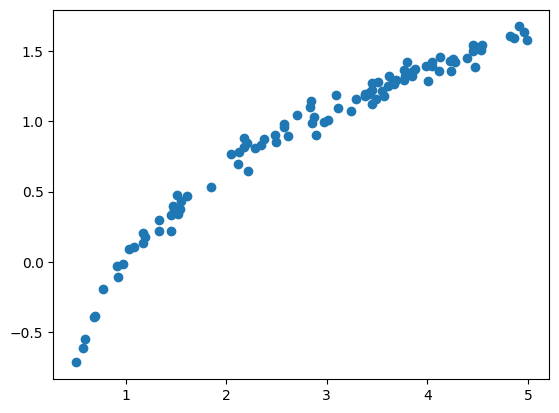

In [19]:
import matplotlib.pyplot as plt
plt.scatter(x, y)

Looks good to me, now let's try to fit a linear model on it with TF:
$$
y = wx+b
$$

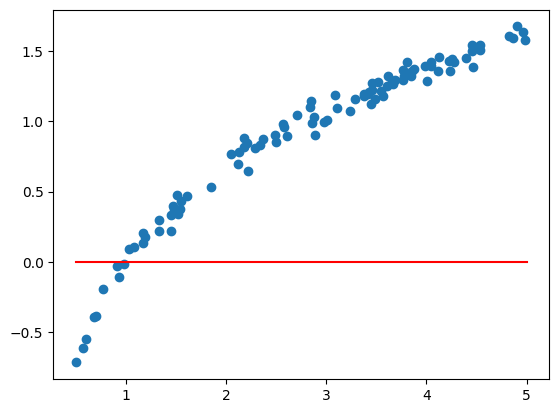

In [20]:
# well, we have one covariate, so we need only one variable
w = tf.Variable(0.)
# and our little friend bias
b = tf.Variable(0.)
# and we will need an optimizer
optimizer = tf.optimizers.Adam(learning_rate=1e-2)

def predict(x):
  return w*x + b

plt.scatter(x, y)
plt.plot([0.5, 5.0], [predict(0.5), predict(5.0)], c="red")

In [21]:
def loss(predictions, targets):
  #print(((targets - predictions)**2).shape)     #always check shapes
  return tf.reduce_mean((targets - predictions)**2)

for i in range(200):
  with tf.GradientTape() as tape:
    l = loss(predict(x), y)

  grad = tape.gradient(l, [w,b])
  optimizer.apply_gradients(zip(grad, [w,b]))
  if i%10 == 0:
    print(f"epoch {i} - loss: {l}")

epoch 0 - loss: 1.172288179397583
epoch 10 - loss: 0.4950064420700073
epoch 20 - loss: 0.16534654796123505
epoch 30 - loss: 0.08254487067461014
epoch 40 - loss: 0.08431074023246765
epoch 50 - loss: 0.08158895373344421
epoch 60 - loss: 0.07320592552423477
epoch 70 - loss: 0.06866687536239624
epoch 80 - loss: 0.06556683778762817
epoch 90 - loss: 0.062138356268405914
epoch 100 - loss: 0.05885940045118332
epoch 110 - loss: 0.055784378200769424
epoch 120 - loss: 0.052828311920166016
epoch 130 - loss: 0.050028182566165924
epoch 140 - loss: 0.04739619418978691
epoch 150 - loss: 0.04493485391139984
epoch 160 - loss: 0.04264917969703674
epoch 170 - loss: 0.04053916409611702
epoch 180 - loss: 0.03860237076878548
epoch 190 - loss: 0.03683430701494217


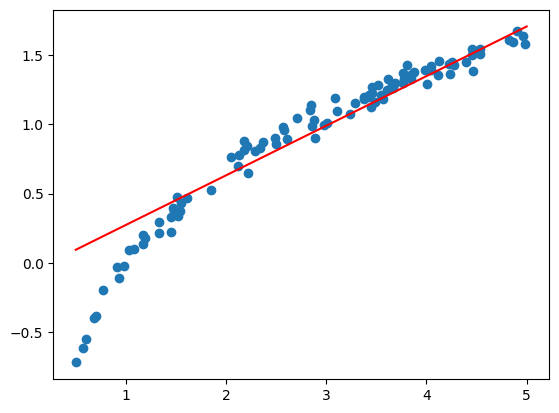

In [22]:
plt.scatter(x, y)
plt.plot([0.5, 5.0], [predict(0.5), predict(5.0)], c="red")

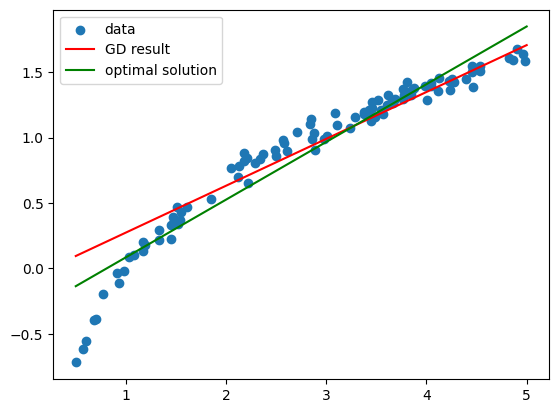

In [23]:
import numpy as np
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(x[..., None], y)
plt.scatter(x, y)
plt.plot([0.5, 5.0], [predict(0.5), predict(5.0)], c="red")
plt.plot([0.5, 5.0], [reg.predict([[0.5]]), reg.predict([[5.0]])], c="green")
plt.legend(["data", "GD result", "optimal solution"])

However, you are engineers, and you would do some more analysis on the model and see that the residuals are kinda bad, and so you would try to alter the data to improve it, right?

Text(0, 0.5, 'residual')

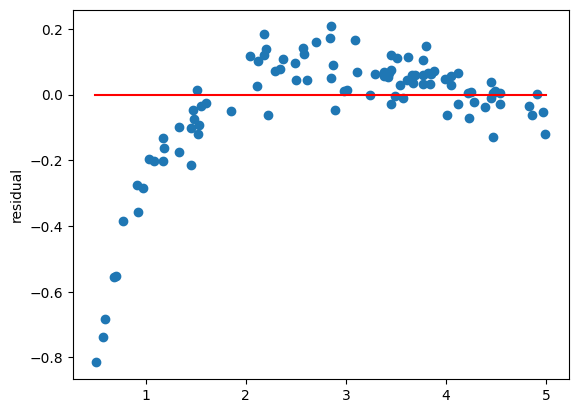

In [24]:
plt.scatter(x, y-predict(x))
plt.plot([0.5, 5.0], [0,0], c="red")
plt.ylabel("residual")

well, that's easy in our model, since we only need to redefine how to predict the target

In [25]:
w = tf.Variable(0.)
w_square = tf.Variable(0.)
b = tf.Variable(0.)
optimizer = tf.optimizers.Adam(learning_rate=1e-1)

def loss(predictions, targets):
  return tf.reduce_mean((targets-predictions)**2)

def predict(x):
  return w_square*x**2 + w*x + b

for i in range(400):
  with tf.GradientTape() as tape:
    l = loss(predict(x), y)

  grad = tape.gradient(l, [w,w_square,b])
  optimizer.apply_gradients(zip(grad, [w,w_square,b]))
  if i%10 == 0:
    print(f"epoch {i} - loss: {l}")

epoch 0 - loss: 1.172288179397583
epoch 10 - loss: 0.29523932933807373
epoch 20 - loss: 0.1413426250219345
epoch 30 - loss: 0.08525346964597702
epoch 40 - loss: 0.056393470615148544
epoch 50 - loss: 0.042173389345407486
epoch 60 - loss: 0.040424250066280365
epoch 70 - loss: 0.03569510951638222
epoch 80 - loss: 0.03278246894478798
epoch 90 - loss: 0.029632605612277985
epoch 100 - loss: 0.02682199887931347
epoch 110 - loss: 0.02425995096564293
epoch 120 - loss: 0.02191641367971897
epoch 130 - loss: 0.019795406609773636
epoch 140 - loss: 0.017895841971039772
epoch 150 - loss: 0.016210755333304405
epoch 160 - loss: 0.014729288406670094
epoch 170 - loss: 0.013438062742352486
epoch 180 - loss: 0.012322016060352325
epoch 190 - loss: 0.011365060694515705
epoch 200 - loss: 0.010550815612077713
epoch 210 - loss: 0.009863195940852165
epoch 220 - loss: 0.009286741726100445
epoch 230 - loss: 0.0088069261983037
epoch 240 - loss: 0.008410336449742317
epoch 250 - loss: 0.008084779605269432
epoch 260 -

In [26]:
w_square

<tf.Variable 'Variable:0' shape=() dtype=float32, numpy=-0.08738511055707932>

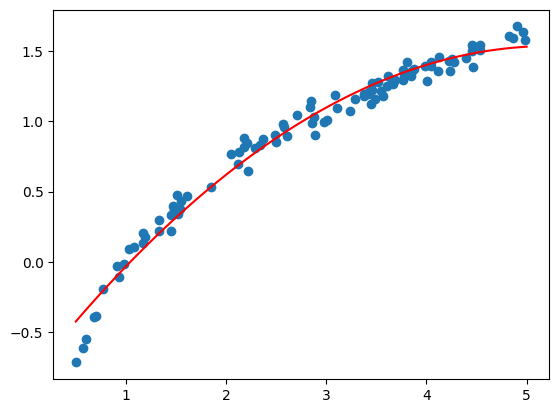

In [27]:
plt.scatter(x, y)
points = np.linspace(0.5, 5.0, 100)
plt.plot(points, predict(tf.cast(points, tf.float32)), c="red")

Text(0, 0.5, 'residual')

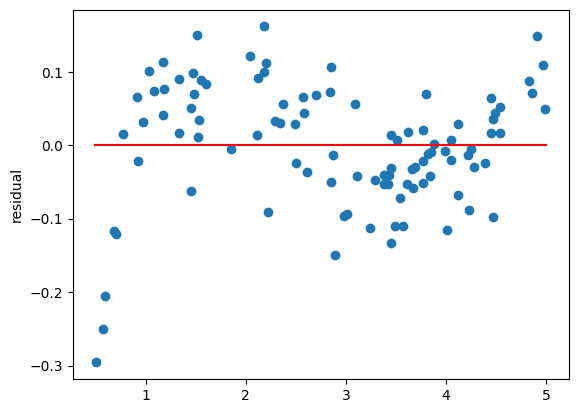

In [28]:
plt.scatter(x, y-predict(x))
plt.plot([0.5, 5.0], [0,0], c="red")
plt.ylabel("residual")
#residuals show a bias, i needed to perform a exp transformation

Say we want to use mean absolute error as loss and not mean squared error, we just need to change it in the code, and TF will handle the rest

In [29]:
w = tf.Variable(0.)
b = tf.Variable(0.)
optimizer = tf.optimizers.Adam(learning_rate=1e-2)

def loss(predictions, targets):
  return tf.reduce_mean(tf.abs(targets-predictions))

def predict(x):
  return w*x + b

for i in range(400):
  with tf.GradientTape() as tape:
    l = loss(predict(x), y)

  grad = tape.gradient(l, [w,b])
  optimizer.apply_gradients(zip(grad, [w,b]))
  if i%10 == 0:
    print(f"epoch {i} - loss: {l}")

epoch 0 - loss: 0.9804307818412781
epoch 10 - loss: 0.6307658553123474
epoch 20 - loss: 0.3307666778564453
epoch 30 - loss: 0.18882682919502258
epoch 40 - loss: 0.160102978348732
epoch 50 - loss: 0.1650494635105133
epoch 60 - loss: 0.15328162908554077
epoch 70 - loss: 0.14456461369991302
epoch 80 - loss: 0.13792425394058228
epoch 90 - loss: 0.13370633125305176
epoch 100 - loss: 0.129827618598938
epoch 110 - loss: 0.12641260027885437
epoch 120 - loss: 0.12354235351085663
epoch 130 - loss: 0.12093114107847214
epoch 140 - loss: 0.11887748539447784
epoch 150 - loss: 0.11692260950803757
epoch 160 - loss: 0.11497115343809128
epoch 170 - loss: 0.113203264772892
epoch 180 - loss: 0.11183921992778778
epoch 190 - loss: 0.11064572632312775
epoch 200 - loss: 0.10954184830188751
epoch 210 - loss: 0.10850884765386581
epoch 220 - loss: 0.10769934952259064
epoch 230 - loss: 0.1071694865822792
epoch 240 - loss: 0.10674258321523666
epoch 250 - loss: 0.10648788511753082
epoch 260 - loss: 0.10630296915769

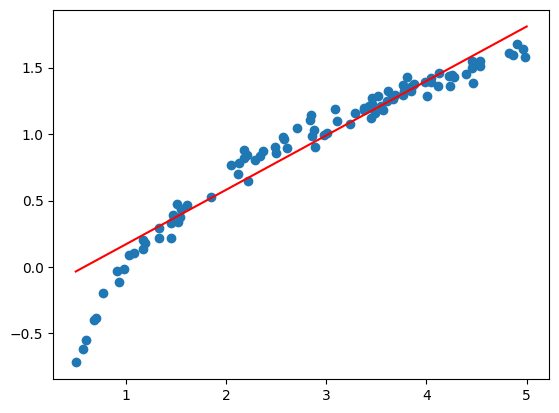

In [30]:
plt.scatter(x, y)
points = np.linspace(0.5, 5.0, 100)
plt.plot(points, predict(tf.cast(points, tf.float32)), c="red")

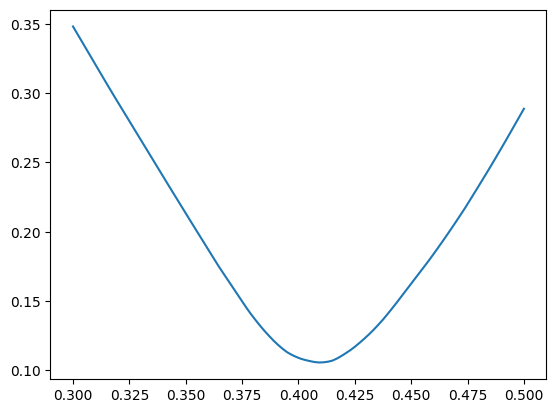

In [31]:
ws = np.linspace(0.3, 0.5, 100)
losses=[]
for w in ws:
  losses.append(loss(predict(x), y))

plt.plot(ws, losses)

![](https://media.tenor.com/J5A9wZzn3ZYAAAAC/robert-redford-jeremiah-johnson.gif)

### Even PCA?

Well, we won't really implement PCA, that has some constraint on the definition of the matrixes, but at the end of the day, is purely a linear transformation of the data, and it has been proven that any linear transformation of it will lead to the same solution or to an equivalent one (same loss)

so, what we need is to minimize the following:
$$
L(\theta) = \sum_x (W^T(Wx) - x)^2
$$
Thus, we first project $x$ to a lower dimensional space via $W$, and via $W^$ we project it back to the original one, and we hope that such projection-back reconstruct $x$ as good as possible (for simplicity, we assume that the mean is 0, so we don't need the bias, but it's trivially fixable, feel free to try)

In [32]:
data = tf.random.normal(shape=(100,10), mean=0., stddev=5.0)
W = tf.Variable(tf.random.normal(shape=(10,2), mean=0., stddev=0.1))
optimizer = tf.optimizers.Adam(learning_rate=1e-2)

def loss(predictions, targets):
  return tf.reduce_mean((predictions - targets)**2)

def predict(x):
  return tf.matmul(tf.matmul(x, W),tf.transpose(W))     #also @ operates matmul  ---> x @ W @ tf.transpose(W)

for i in range(1000):
  with tf.GradientTape() as tape:
    l = loss(predict(data), data)

  grad = tape.gradient(l, [W])
  optimizer.apply_gradients(zip(grad, [W]))
  if i%10 == 0:
    print(f"epoch {i} - loss: {l}")

epoch 0 - loss: 23.27561378479004
epoch 10 - loss: 21.533769607543945
epoch 20 - loss: 20.127235412597656
epoch 30 - loss: 18.781015396118164
epoch 40 - loss: 17.86786460876465
epoch 50 - loss: 17.627103805541992
epoch 60 - loss: 17.224735260009766
epoch 70 - loss: 16.959821701049805
epoch 80 - loss: 16.793424606323242
epoch 90 - loss: 16.700027465820312
epoch 100 - loss: 16.655702590942383
epoch 110 - loss: 16.63372230529785
epoch 120 - loss: 16.62159538269043
epoch 130 - loss: 16.6142578125
epoch 140 - loss: 16.60940933227539
epoch 150 - loss: 16.606029510498047
epoch 160 - loss: 16.603532791137695
epoch 170 - loss: 16.601558685302734
epoch 180 - loss: 16.599885940551758
epoch 190 - loss: 16.598403930664062
epoch 200 - loss: 16.59706687927246
epoch 210 - loss: 16.59584617614746
epoch 220 - loss: 16.59473419189453
epoch 230 - loss: 16.593725204467773
epoch 240 - loss: 16.592811584472656
epoch 250 - loss: 16.591991424560547
epoch 260 - loss: 16.59126091003418
epoch 270 - loss: 16.59061

In [33]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
res = pca.fit_transform(data)
rec = pca.inverse_transform(res)
print(f"MSE closed form: {((data.numpy() - rec)**2).mean()} - MSE gradient solution: {((predict(data) - data).numpy()**2).mean()}")

MSE closed form: 16.39526016278543 - MSE gradient solution: 16.586708068847656


## Let's go hardcore, neural network time

Ever coded a neural network from scratch? Well, for those who said not, it's time to finally do it right?

For the data, say we will have 6 dimensions, some will be used, some won't

In [34]:
data = tf.random.normal((1000, 6))
# the target is unreadable on purpose, I'm just applying random non linear transformation to the data, plus some noise
targets = tf.sqrt(tf.abs(
              (data[:, 0] * 10)**2 +
              tf.exp(data[:, 1]) -
               (data[:, 3] + data[:, 5]) /
              tf.abs(data[:, 4]))
) + tf.random.normal((1000,))

Now, let's recall that a fully connected layer is composed by the following:
$$
x \in R^n\\
W \in R^{n\times m}\\
b \in R^m\\
\\
output = \sigma(Wx + b)\\
$$

Well, doesn't seem too different from what we have done so far right? Then let's go on implementing it (the index in the variable refers to each layer)

In [35]:
DIMS = 1000 # middle layer dimension
initializer = tf.initializers.RandomNormal(seed=0)
# from 6 to DIMS
W1 = tf.Variable(initial_value=initializer((data.shape[1], DIMS)))
b1 = tf.Variable(initial_value=initializer((DIMS,)))
# from DIMS to 1
W2 = tf.Variable(initial_value=initializer((DIMS, 1)))
b2 = tf.Variable(initial_value=initializer((1,)))

In [37]:
optimizer = tf.optimizers.Adam(learning_rate=1e-3)

def loss(predictions, targets):
  # !!!!!! the [..., None]  is necessary to match the shapes,
  #        what it does is add a new dimension to the array: (N,M) => (N,M,1)
  return tf.reduce_mean(tf.square(predictions - targets[..., None]))

non_linearity = tf.nn.tanh

def predict(x):
  # HINT: the @ operator is just an alias for matrix multiplication
  x = non_linearity(x@W1 + b1)
  return x@W2 + b2


for i in range(1000):
  with tf.GradientTape() as tape:
    l = loss(predict(data), targets)

  grad = tape.gradient(l, [W1,b1,W2,b2])
  optimizer.apply_gradients(zip(grad, [W1,b1,W2,b2]))
  if i%10 == 0:
    print(f"epoch {i} - loss: {l}")

epoch 0 - loss: 71.75296783447266
epoch 10 - loss: 61.40339660644531
epoch 20 - loss: 51.44357681274414
epoch 30 - loss: 42.55257797241211
epoch 40 - loss: 37.198455810546875
epoch 50 - loss: 35.876590728759766
epoch 60 - loss: 36.06057357788086
epoch 70 - loss: 35.922584533691406
epoch 80 - loss: 35.81149673461914
epoch 90 - loss: 35.79842758178711
epoch 100 - loss: 35.771026611328125
epoch 110 - loss: 35.740997314453125
epoch 120 - loss: 35.712867736816406
epoch 130 - loss: 35.68095779418945
epoch 140 - loss: 35.646053314208984
epoch 150 - loss: 35.607818603515625
epoch 160 - loss: 35.565956115722656
epoch 170 - loss: 35.52064895629883
epoch 180 - loss: 35.47218704223633
epoch 190 - loss: 35.421112060546875
epoch 200 - loss: 35.368247985839844
epoch 210 - loss: 35.3145866394043
epoch 220 - loss: 35.26121520996094
epoch 230 - loss: 35.20912170410156
epoch 240 - loss: 35.158973693847656
epoch 250 - loss: 35.11099624633789
epoch 260 - loss: 35.06492614746094
epoch 270 - loss: 35.0200157

## Let's go TF - long life to OOP

This was all, the last part is going TF, meaning to use OOP to actually make everything interact with Tensorflow correctly, but it's just a matter of reading the doc... in this way, you'll be able to take advantage of all the code that TF and Keras provides you

You will have to deal mainly with 2 classes:

 1. `tf.keras.Model` to redefine a model (so a NN)
 2. `tf.keras.layers.Layer` to redefine a layer

Let's create a fully connected layer in a OOP way

In [38]:
class FCLayer(tf.keras.layers.Layer):
  def __init__(self, dim, non_linearity=None, **kwargs):
    super().__init__(**kwargs)
    self.dim = dim
    self.non_linearity = non_linearity
  # function called on the first call, that builds the network (now you know the shape of the input, so you can build the matrixes)
  def build(self, input_shape):
    self.W = self.add_weight(name="W", shape=(input_shape[-1], self.dim), initializer=tf.initializers.RandomNormal())
    self.b = self.add_weight(name="b", shape=(self.dim, 1), initializer=tf.initializers.RandomNormal())
  # function called when you predict, so every time you do model(), or model.call(), or model.predict()
  def call(self, inputs, *args, **kwargs):
    transformed = inputs@self.W + self.b
    return self.non_linearity(transformed) if self.non_linearity is not None else transformed

In [39]:
model = tf.keras.Sequential([
  FCLayer(100, tf.nn.tanh),
  FCLayer(100, tf.nn.tanh),
  FCLayer(1,)
])

In [40]:
model.compile(optimizer=tf.optimizers.Adam(1e-3), loss=tf.keras.losses.MeanSquaredError())

In [41]:
model.fit(data, targets, batch_size=100, epochs=1000)

Epoch 1/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 97.6514 
Epoch 2/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 94.1944 
Epoch 3/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 104.4348 
Epoch 4/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 96.0188 
Epoch 5/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 87.4457 
Epoch 6/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 72.3560 
Epoch 7/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 62.5229 
Epoch 8/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 49.3934 
Epoch 9/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 42.1734 
Epoch 10/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 36.7957 
Epoch 11/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 38.5344 
Epoch 12/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 34.8218 
Epoch 13/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 38.3801 
Epoch 14/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 36.2430 
Epoch 15/1000
10/10 ━━━━━━━━

Sometimes you might want to manually control the forward process, or do some data augmentation on the fly, or whatever, and to do so, you instead use the `Model` class... say you want to have 2 separate layers in the middle, thing that you cannot control with the `Sequential` API
```
   input
     |
     l1
    / \
   l2  l3
    \ /
     +
     |
     l4
     |
```

(you can do it with the functional API, it's a bit more cumbersome imho, but i encourage you to [give it a look](https://www.tensorflow.org/guide/keras/functional_api), it's definitely easier for simple cases like this)

In [47]:
class MyModel(tf.keras.Model):
  def __init__(self, *args, **kwargs):
    super().__init__(*args, **kwargs)
    self.l1 = FCLayer(100, tf.nn.tanh)
    self.l2 = FCLayer(100, tf.nn.tanh)
    self.l3 = FCLayer(100, tf.nn.tanh)
    self.l4 = FCLayer(1,)
  def train_step(self, data):
    x,y = data
    with tf.GradientTape() as tape:
      x = self.l1(x)
      x = self.l2(x)+self.l3(x)
      predictions = self.l4(x)
      loss = self.compiled_loss(y, predictions)
    grad = tape.gradient(loss, self.trainable_weights)
    self.optimizer.apply_gradients(zip(grad, self.trainable_weights))
    return {
      "loss": loss
    }

In [48]:
model = MyModel()
model.compile(optimizer=tf.optimizers.Adam(1e-3), loss=tf.keras.losses.MeanSquaredError())
model.fit(data, targets, batch_size=100, epochs=1000)

Epoch 1/1000


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:671: UserWarning: `model.compiled_loss()` is deprecated. Instead, use `model.compute_loss(x, y, y_pred, sample_weight, training)`.
  warnings.warn(


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 92.5492 
Epoch 2/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 91.5691  
Epoch 3/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 88.8441 
Epoch 4/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 83.1941 
Epoch 5/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 73.7750 
Epoch 6/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 61.8045 
Epoch 7/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 50.5735 
Epoch 8/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 42.5019 
Epoch 9/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 38.2520 
Epoch 10/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 37.7421 
Epoch 11/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 35.1948 
Epoch 12/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 34.1628 
Epoch 13/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 34.7390 
Epoch 14/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 33.8986 
Epoch 15/1000
10/10 ━━━━━━━━━━━━━━━━━━━━ 

And now, thanks to the magic of OOP, you can mix your blocks of code with parts coming from other developers, hopefully without loosing too many hours adapting it

### Real world scenario

In [49]:
from tensorflow.keras import datasets, layers, models
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 259s 2us/step


In [50]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [51]:
# consider that in real life, you also have to do a lot of others stuff, from hyperparameter-tuning, to data cleaning and so on
# the first step, is to check the loss of your network, to avoid overfitting
# to do that , we will use a held-out-part of the dataset, where keras will validate the model after every epoch
model.compile(optimizer=tf.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=10,validation_split=0.2)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.3272 - loss: 1.8130 - val_accuracy: 0.5428 - val_loss: 1.2883
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5644 - loss: 1.2196 - val_accuracy: 0.6007 - val_loss: 1.1435
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6334 - loss: 1.0468 - val_accuracy: 0.6500 - val_loss: 1.0018
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6748 - loss: 0.9326 - val_accuracy: 0.6671 - val_loss: 0.9644
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7039 - loss: 0.8388 - val_accuracy: 0.6676 - val_loss: 0.9451
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7253 - loss: 0.7829 - val_accuracy: 0.6856 - val_loss: 0.9214
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7472 - loss: 0.7199 - val_accuracy: 0.6970 - val_loss: 0.9033
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7723 - loss: 0.6533 -

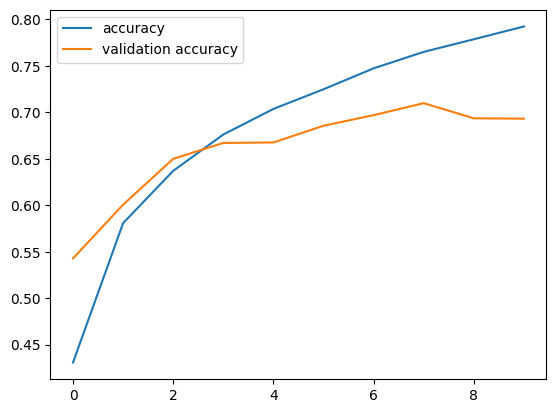

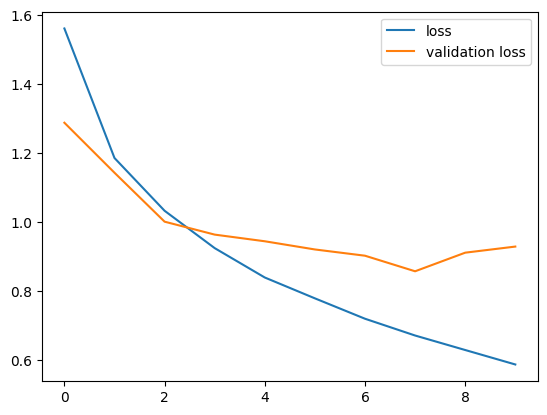

In [52]:
import matplotlib.pyplot as plt
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["accuracy", "validation accuracy"])
plt.show()
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.legend(["loss", "validation loss"])
plt.show()

That was all from me, hope that it was clear and that you liked it, feel free to experiment a bit, next time we will start from here and use the custom training loop that we saw earlier to train a RL agent

Have funnnnnnnnn


![](https://media.tenor.com/lfDHEnYIUk4AAAAC/this-is-where-the-fun-begins-star-wars.gif)

## (Fun) Exercises

For the braves, I leave here some exercises (they should be pretty simple) to explore a bit and test your knowledge.

I'll give you the main structure of the code and you can just complete it, however, to achieve the same results, there are hundreds of ways, so if you find my scaffolding too cumbersome, or you think there is a better way (let alone possible errors), feel free to experiment... ad if you have questions, feel free to write me at [alberto.sinigaglia@phd.unipd.it](mailto:alberto.sinigaglia@phd.unipd.it)

### Batch Normalization

[Batch Normalization](https://arxiv.org/abs/1502.03167) is a very famous building block for neural networks, it is fundamental for big models, as it solves (tackles at least) a very famous problem in deep hierarchical models, called _internal covariate shift_... in poor words, when you change the parameters in the initial layers, their change is amplified by the change in the next layers, and when you get to the final layers, you have a completely different representation for the same image, thus the final layer has to be trained from scratch.

What BN do is pretty simple, and it's, as the name suggests, a normalization of each batch (intra network, so it's not just a preprocessing).
Given a batch of data of size $N$, BN applied to the $M$th layer, forward propagates the batch in the previous layers, obtaining the batch tensor $t$, and does the following:
$$
\mu = \frac{\sum_{i=0}^N t_i}{N} \\
\sigma^2 = \frac{\sum_{i=0}^N (t_i - \mu)^2}{N} \\
\hat{t} = \frac{t - \mu}{\sqrt{\sigma} + \epsilon}\\
t_\text{final} = \gamma \hat{t} + \beta
$$
in poor words, it first normalizes the batch, and then rescales and shift the tensor using $\beta, \gamma$, which are trained parameters, so that the network is free to learn where is best to have such distribution.

Let's create a Layer that does exactly that (actually, usually $\mu, \sigma$ are moving average, because you need a good statistic for this to work)

In [60]:
# we assume to be doing the normalization on the last dimension of the batch, so for images, we normalize per channel
class CustomBatchNormalization(tf.keras.layers.Layer):
  def __init__(self, eps=1e-6, momentum=0.5, **kwargs):
    super().__init__(**kwargs)
    self.beta = None # final shift
    self.alpha = None # final rescale
    self.moving_std = None # moving average of the variance
    self.moving_mean = None # moving average of the mean
    self.eps = eps # epsilon, for stability
    self.momentum = momentum # momentum of the moving average
  def build(self, input_shape):
    # we initialize the parameters as we have seen until now, so there should be nothing new here
    self.alpha = self.add_weight(name="alpha", shape=(input_shape[-1],))
    self.beta = self.add_weight(name="beta", shape=(input_shape[-1],))
    self.moving_mean = self.add_weight(name="moving mean", shape=(input_shape[-1],), initializer ='zeros', trainable=False)
    self.moving_std = self.add_weight(name="moving std", shape=(input_shape[-1],), initializer ='ones', trainable=False)
  def call(self, inputs, training=False, *args, **kwargs):
    # during training, we want to update the statistics
    if training:
      mean = tf.reduce_mean(inputs, axis=(0,1,2), name="batch_mean")
      std = tf.math.reduce_std(inputs, axis=(0,1,2), name="batch_std")
      self.moving_mean.assign(self.momentum*self.moving_mean + (1-self.momentum)*mean)
      self.moving_std.assign(self.momentum*self.moving_std + (1-self.momentum)*std)
    # reshape to allow tensor propagation
    mean = tf.reshape(self.moving_mean, (1, 1, -1))
    std = tf.reshape(self.moving_mean, (1, 1, -1))

    processed_inputs = (inputs - mean)/(std + self.eps)
    return self.alpha*processed_inputs + self.beta

In [61]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(CustomBatchNormalization())
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [62]:
model.compile(optimizer=tf.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=10,validation_split=0.2)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.3203 - loss: 1.8448 - val_accuracy: 0.5118 - val_loss: 1.3481
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5372 - loss: 1.2972 - val_accuracy: 0.5624 - val_loss: 1.2209
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5974 - loss: 1.1369 - val_accuracy: 0.6118 - val_loss: 1.1158
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6369 - loss: 1.0298 - val_accuracy: 0.6224 - val_loss: 1.0788
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6674 - loss: 0.9509 - val_accuracy: 0.6307 - val_loss: 1.0726
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6944 - loss: 0.8685 - val_accuracy: 0.6591 - val_loss: 0.9904
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7184 - loss: 0.7997 - val_accuracy: 0.6607 - val_loss: 0.9918
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7319 - loss: 0.7641 - 

### Residual connection

[Residual networks](https://arxiv.org/abs/1512.03385) are the other big famous super used building block for big networks. They solve an orthogonal problem to the one of BN, which is the vanishing gradient. What was observed before ResNet was that deep networks performed better than shallow networks, up to a certain point, and then performances worsened.

The problem is that given a N layer network, you can easily approximate it with a M layer network (M > N), by setting its first N layers with the same weights as the other network, and then the last M-N with an identity function.

However, layers are initialized so that they approximate the zero-function (weights close to 0), so the network has a hard time learning the identity.

To solve that, they just added a residual connection, which is "you some to your output, your input" (given that they have the same shape, otherwise you can concatenate it in some way):
$$
y_i = F(x_i) + x_i
$$
That's all... the intuition is that $F(x_i)$ is initialized with the 0-function, so if it's useless (like the last M-N layers in the previous example), you can just not learn anything in the last layers, and forward the information.

You can also think this as a "gradient descent" idea, where indeed GD has as update $x_i = x_i + F(x_i)$, where $F$ is just the gradient.


Let's code it!

In [63]:
class CustomResidualLayer(tf.keras.layers.Layer):
  # ffnn want's to be whatever stays between the input and the residual connection, which can be a single layer, or a whole model, makes no difference
  def __init__(self, ffnn, **kwargs):
    super().__init__(**kwargs)
    self.ffnn = tf.keras.models.Sequential(ffnn)

  def call(self, inputs, *args, **kwargs):
    return self.ffnn(inputs)+inputs

In [64]:
model = models.Sequential()
model.add(layers.Conv2D(64, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(
  CustomResidualLayer([
    layers.Conv2D(64, (3, 3), activation='relu', padding="SAME"),
    layers.Conv2D(64, (3, 3), activation='relu', padding="SAME"),
  ])
)
model.add(layers.MaxPooling2D((2, 2)))
model.add(
  CustomResidualLayer([
    layers.Conv2D(64, (3, 3), activation='relu', padding="SAME"),
    layers.Conv2D(64, (3, 3), activation='relu', padding="SAME"),
  ])
)
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer=tf.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=10,validation_split=0.2)

Epoch 1/10
 825/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2885 - loss: 1.9339

### Dropout

[Dropout](https://arxiv.org/abs/1207.0580) is a very famous regularization method proposed from Hinton, that has a toooon of intuitions behind it... in very few words, it just randomly sets values to 0 with some probability (that you choose)

You can see this as a "regularization" since the network cannot rely always on the same information/neuron to predict, or you can see this as a cheap way of training an ensemble of neural networks.

To do so, we just do the following:
$$
m \sim Be(p) ^ {N} \\
y_i = F(x_i) \cdot m
$$

So it's pretty simple, we just need to create a layer that samples random binary masks form a Bernoulli distribution, and multiply.
At test time, we keep all the neurons on and we rescale the activation by $1-p$ (since you would have only $p$ active neurons, you "overstimulate the neuron if you activate all connections without rescaling the sum)

Let's do it.

![](https://media.tenor.com/JOJ1qSZon7UAAAAC/shia-labeouf-just-do-it.gif)

In [66]:
class CustomDropoutLayer(tf.keras.layers.Layer):
  def __init__(self, prob):
    super(CustomDropoutLayer, self).__init__()
    self.prob = prob

  def call(self, inputs, training=None):
    if training:
      # Generate a random mask with the same shape as the inputs
      mask = mask = tf.cast(
                tf.random.uniform(shape=tf.shape(inputs)) >= self.prob,
                dtype=inputs.dtype
            )
      masked_inputs = mask * inputs / (1-self.prob)
      return masked_inputs
    return inputs

In [67]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(CustomDropoutLayer(0.5))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [68]:
model.compile(optimizer=tf.optimizers.Adam(),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(train_images, train_labels, epochs=10,validation_split=0.2)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.3060 - loss: 1.8585 - val_accuracy: 0.5164 - val_loss: 1.3635
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5178 - loss: 1.3367 - val_accuracy: 0.5622 - val_loss: 1.2344
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5783 - loss: 1.1800 - val_accuracy: 0.6048 - val_loss: 1.1300
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6104 - loss: 1.1005 - val_accuracy: 0.6444 - val_loss: 1.0168
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6393 - loss: 1.0197 - val_accuracy: 0.6555 - val_loss: 0.9966
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6663 - loss: 0.9525 - val_accuracy: 0.6603 - val_loss: 0.9750
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6832 - loss: 0.9013 - val_accuracy: 0.6694 - val_loss: 0.9343
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6956 - loss: 0.8642 -

### References to other possible fun projects

If you are interested in Deep Neural Networks, you can try to implement the following models:
 - Autoencoder
 - ResNet
 - Transformers
 - Variational Autoencoder
 - Generative Adverasarial Networks / Pix2Pix
 - Siamese Networks

For most of them there are already existing clean implementation from which you can take inspiration, I ranked them by difficulty, so maybe start from the initial ones and then move to the next